# Neutral-set sanity check

Load an NNSE `.npz`, print bin statistics for saved neutral coordinates, and plot random representative trajectories against the wild-type output. Set `CHEN = True` for Chen 2004 and `CHEN = False` for Tyson 1991. By default this notebook selects the largest available merged neutral-set file; set `NPZ_PATH` manually in the next cell to inspect a specific run.

In [7]:
%matplotlib inline
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# If the notebook is opened from WhySystemsBiologyWorks/NNSE, ROOT is the parent.
ROOT = Path.cwd()
if ROOT.name == "NNSE":
    ROOT = ROOT.parent
if not (ROOT / "wsbw_pipeline.py").exists():
    # Fallback for running from repo root or another working directory.
    candidates = [Path.cwd() / "WhySystemsBiologyWorks", Path.cwd()]
    ROOT = next(path for path in candidates if (path / "wsbw_pipeline.py").exists())
sys.path.insert(0, str(ROOT))

from wsbw_pipeline import prepare_models
from wsbw_nnse import get_spec, setup_rr, simulate_output
from nnse_accessibility import choose_biggest_neutral_npz

# Switch this to False for Tyson 1991.
CHEN = True
MODEL_KEY = "chen2004" if CHEN else "tyson1991"
# Leave as None to inspect the largest available neutral-set file for MODEL_KEY.
# Or set, e.g.: NPZ_PATH = ROOT / "results" / "nnse_parallel" / "my_tag" / "chen2004_nnse_parallel_merged_25chains.npz"
NPZ_PATH = None
# Default thresholds: Chen uses the NNSE neutral threshold; Tyson init sweeps are easier to inspect at f <= 1.
NEUTRAL_THRESHOLD = 15.0 if CHEN else 1.0
N_REPRESENTATIVES = 20
SEED = 123

if NPZ_PATH is None:
    NPZ_PATH = choose_biggest_neutral_npz(ROOT, MODEL_KEY)

print("ROOT:", ROOT)
print("NPZ_PATH:", NPZ_PATH)

ROOT: /Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/WhySystemsBiologyWorks
NPZ_PATH: /Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/WhySystemsBiologyWorks/results/nnse_parallel/chen_nnse_parallel_25chains_100k_thr15/chen2004_nnse_parallel_merged_25chains.npz


In [2]:
data = np.load(NPZ_PATH, allow_pickle=True)
print("Arrays in file:")
for key in sorted(data.files):
    arr = data[key]
    print(f"  {key:28s} shape={arr.shape} dtype={arr.dtype}")

thresholds = np.asarray(data["bin_thresholds"], dtype=float)
param_names = [str(x) for x in data["parameter_names"]]
p0 = np.asarray(data["p0"], dtype=float)

if "neutral_points" in data.files and len(data["neutral_points"]):
    points_all = np.asarray(data["neutral_points"], dtype=float)
    values_all = np.asarray(data["neutral_objective_values"], dtype=float)
    if len(values_all) != len(points_all):
        n = min(len(values_all), len(points_all))
        print(f"Warning: neutral_points and neutral_objective_values have different lengths; truncating to {n:,} rows")
        points_all = points_all[:n]
        values_all = values_all[:n]
    mask = np.all(np.isfinite(points_all), axis=1) & np.isfinite(values_all) & (values_all <= NEUTRAL_THRESHOLD)
    points = points_all[mask]
    values = values_all[mask]
    source = f"neutral_points with f <= {NEUTRAL_THRESHOLD}"
elif "candidate_vectors" in data.files and "candidate_objective_values" in data.files:
    # Batch-init files store screened candidates rather than NNSE neutral_points.
    candidates = np.asarray(data["candidate_vectors"], dtype=float)
    vals = np.asarray(data["candidate_objective_values"], dtype=float)
    mask = np.all(np.isfinite(candidates), axis=1) & np.isfinite(vals) & (vals <= NEUTRAL_THRESHOLD)
    points = candidates[mask]
    values = vals[mask]
    source = f"candidate_vectors with f <= {NEUTRAL_THRESHOLD}"
else:
    # Fallback: useful while debugging a run that did not save neutral_points.
    pop = np.asarray(data["final_population"], dtype=float)
    vals = np.asarray(data["final_objective_values"], dtype=float)
    mask = np.all(np.isfinite(pop), axis=1) & np.isfinite(vals) & (vals <= NEUTRAL_THRESHOLD)
    points = pop[mask]
    values = vals[mask]
    source = f"final_population with f <= {NEUTRAL_THRESHOLD}"

print(f"\nLoaded {len(points):,} candidate neutral coordinates from {source}")
if len(values):
    print(f"objective min/median/max: {np.min(values):.6g} / {np.median(values):.6g} / {np.max(values):.6g}")
print("parameter count:", len(param_names))

Arrays in file:
  best_history_by_chain        shape=(25, 100000) dtype=float64
  bin_thresholds               shape=(51,) dtype=float64
  chain_files                  shape=(25,) dtype=object
  chain_steps                  shape=(25,) dtype=int64
  final_objective_values       shape=(25, 51) dtype=float64
  final_populations            shape=(25, 51, 136) dtype=float64
  neutral_objective_values     shape=(133293,) dtype=float64
  neutral_points               shape=(133293, 136) dtype=float64
  p0                           shape=(136,) dtype=float64
  parameter_names              shape=(136,) dtype=object
  reference_signal             shape=(967,) dtype=float64
  reference_time               shape=(967,) dtype=float64

Loaded 133,293 candidate neutral coordinates from neutral_points
objective min/median/max: 0.0577787 / 3.57203 / 14.9995
parameter count: 136


In [3]:
def bin_index(value, thresholds):
    idx = int(np.searchsorted(thresholds, value, side="left"))
    return min(idx, len(thresholds) - 1)

bin_ids = np.array([bin_index(v, thresholds) for v in values], dtype=int) if len(values) else np.array([], dtype=int)

print("Bin counts for bins 0-9:")
for i in range(10):
    lo = 0.0 if i == 0 else thresholds[i - 1]
    hi = thresholds[i]
    n = int(np.sum(bin_ids == i))
    print(f"bin {i:2d}: threshold <= {hi:10.6g}   count={n:8d}")

if len(bin_ids):
    unique, counts = np.unique(bin_ids, return_counts=True)
    print("\nAll occupied bins:")
    for i, n in zip(unique, counts):
        print(f"bin {int(i):2d}: threshold <= {thresholds[int(i)]:10.6g}   count={int(n):8d}")
else:
    print("No neutral coordinates available for bin statistics.")

Bin counts for bins 0-9:
bin  0: threshold <=       0.01   count=       0
bin  1: threshold <=  0.0122957   count=       0
bin  2: threshold <=  0.0151185   count=       0
bin  3: threshold <=  0.0185892   count=       0
bin  4: threshold <=  0.0228568   count=       0
bin  5: threshold <=  0.0281041   count=       0
bin  6: threshold <=   0.034556   count=       0
bin  7: threshold <=  0.0424891   count=       0
bin  8: threshold <=  0.0522434   count=       0
bin  9: threshold <=  0.0642369   count=       1

All occupied bins:
bin  9: threshold <=  0.0642369   count=       1
bin 10: threshold <=  0.0789839   count=       2
bin 11: threshold <=  0.0971164   count=      10
bin 12: threshold <=   0.119412   count=       7
bin 13: threshold <=   0.146825   count=      35
bin 14: threshold <=   0.180532   count=      41
bin 15: threshold <=   0.221977   count=     110
bin 16: threshold <=   0.272937   count=     129
bin 17: threshold <=   0.335595   count=     255
bin 18: threshold <=   0

In [4]:
audit = prepare_models()
spec = get_spec(MODEL_KEY)
audit_item = audit[spec.key]
params = audit_item["free_parameters"]
if params != param_names:
    raise ValueError("Parameter names in the npz do not match the current model audit")

rr, defaults, initials = setup_rr(spec, audit_item["promoted_sbml"], params)
reference = simulate_output(rr, spec, defaults, initials, params, p0)
if reference is None:
    raise RuntimeError("Wild-type reference simulation failed")
t_ref, y_ref = reference
print(f"Reference: {spec.label}, output={spec.output}, points={len(t_ref)}")

Reference: Chen 2004, output=CLB2, points=967


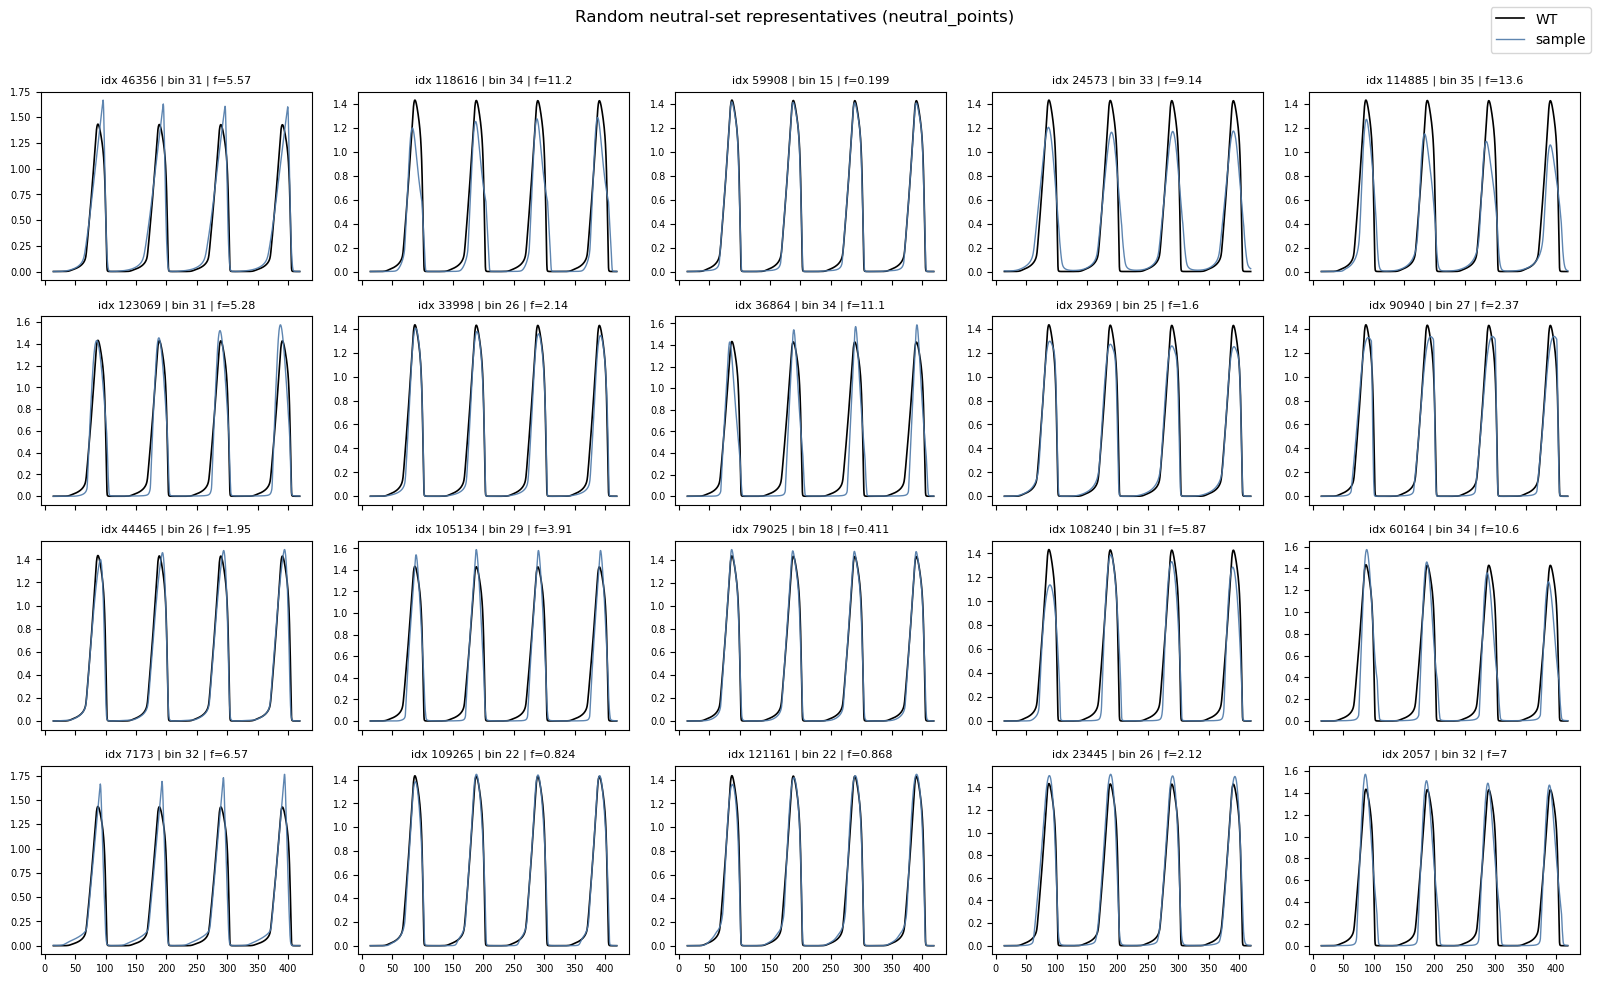

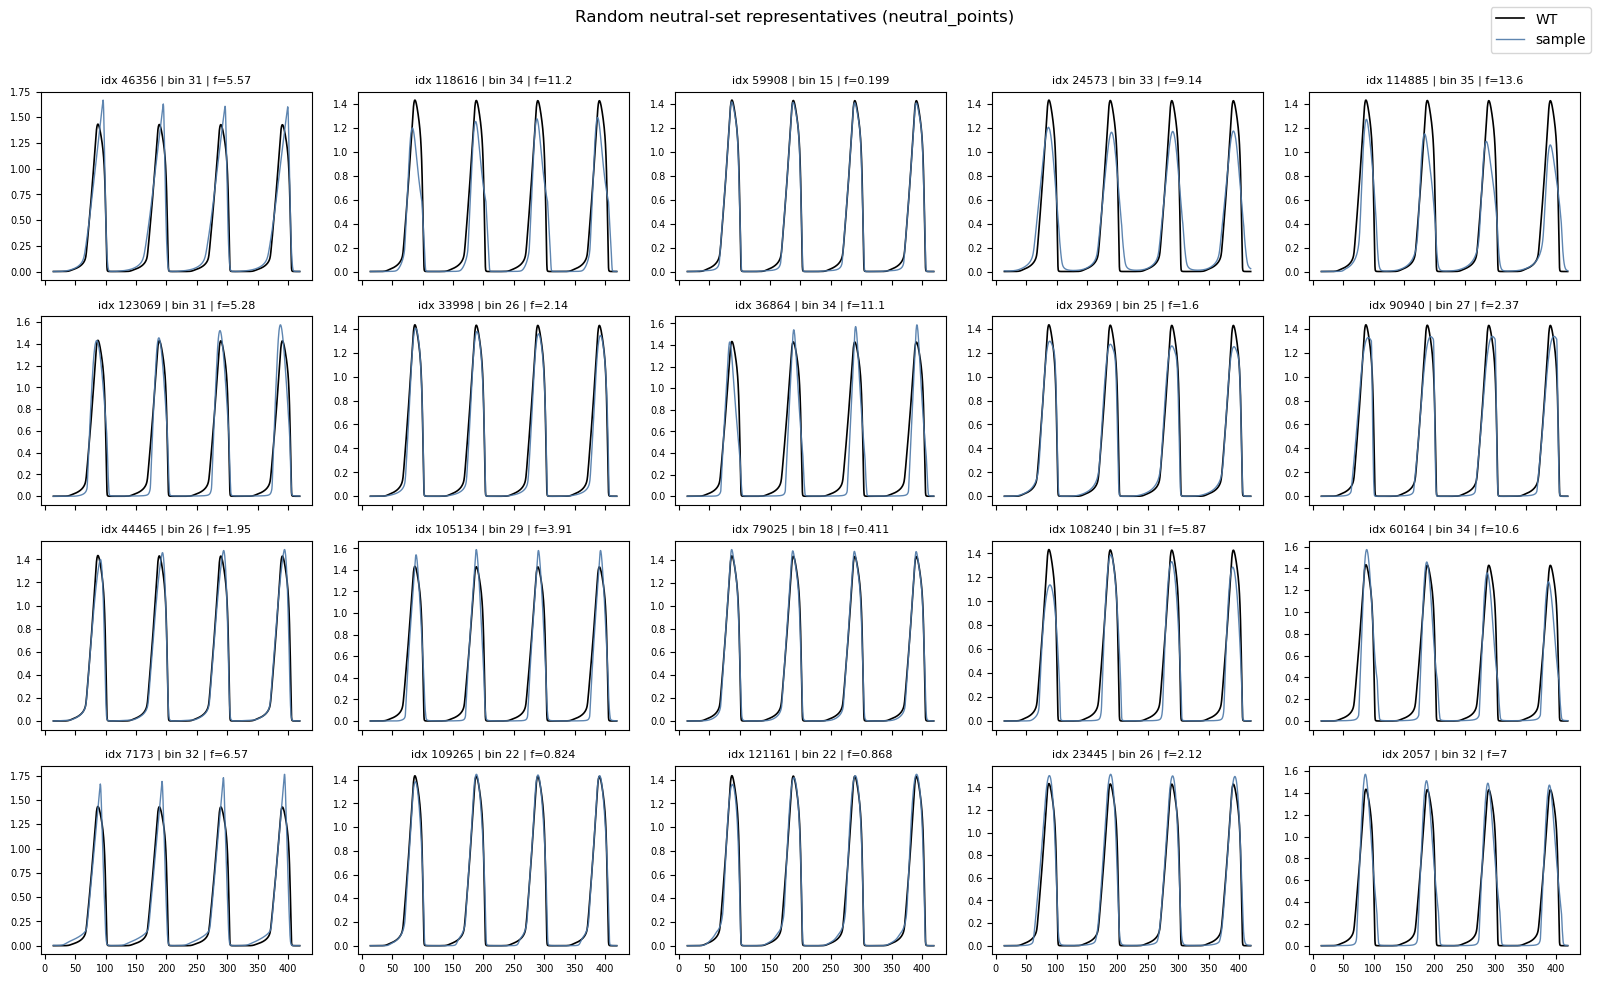

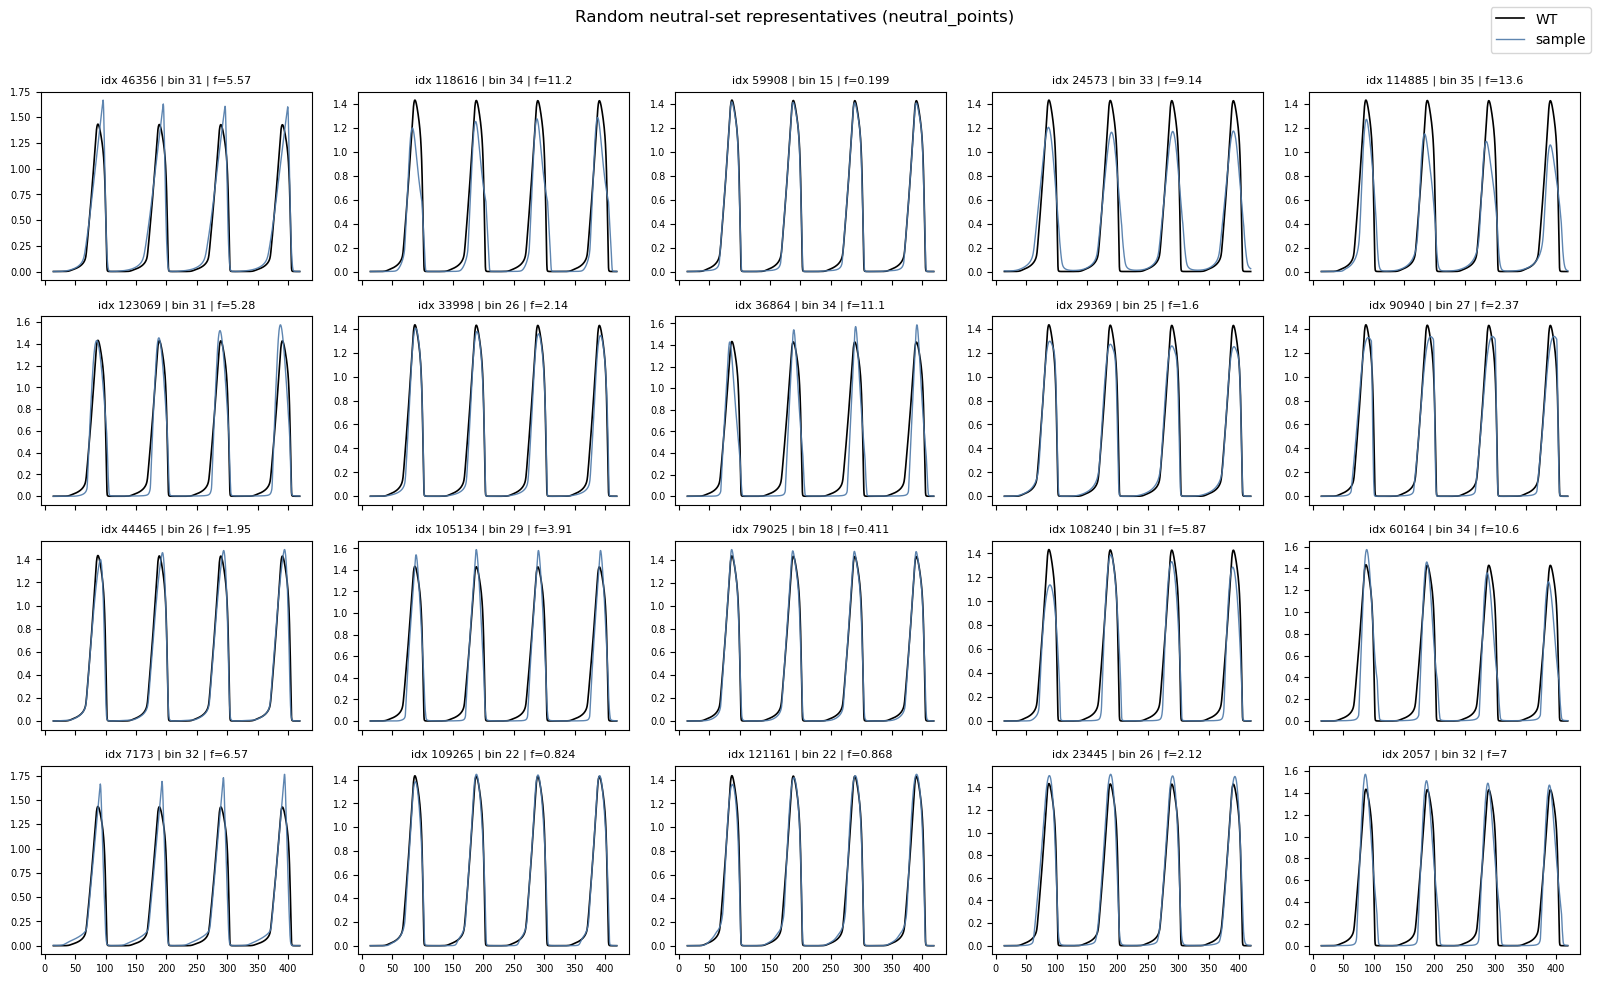

In [8]:
if len(points) == 0:
    raise RuntimeError("No neutral coordinates to plot")

rng = np.random.default_rng(SEED)
n_show = min(N_REPRESENTATIVES, len(points))
chosen = rng.choice(len(points), size=n_show, replace=False)

ncols = 5
nrows = int(np.ceil(n_show / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, idx in zip(axes, chosen):
    out = simulate_output(rr, spec, defaults, initials, params, points[idx])
    ax.plot(t_ref, y_ref, color="black", lw=1.2, label="WT")
    if out is None:
        ax.text(0.5, 0.5, "simulation failed", ha="center", va="center", transform=ax.transAxes)
    else:
        t, y = out
        ax.plot(t, y, color="#4C78A8", lw=1.0, alpha=0.9, label="sample")
    b = bin_index(values[idx], thresholds)
    ax.set_title(f"idx {idx} | bin {b} | f={values[idx]:.3g}", fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes[n_show:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle(f"Random neutral-set representatives ({source})", y=1.02)
fig.tight_layout()
plt.show()

## Next geometry analysis

After this sanity check, the next analysis is the accessibility/null-geometry comparison: compute distances from random parameter points to the NNSE neutral cloud, then compare those distances against null geometries such as compact balls or boxes, ellipsoids matched to the Hessian spectrum, shuffled NNSE clouds preserving marginal coordinate ranges, and synthetic tube/loop clouds.